In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from mlxtend.plotting import plot_decision_regions
import pickle

In [89]:
df = pd.read_csv("placement.csv")

In [90]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [91]:
df.shape

(100, 4)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [93]:
 #now we will remove this column 	Unnamed: 0 with the iloc
df = df.iloc[:,1:]

In [94]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


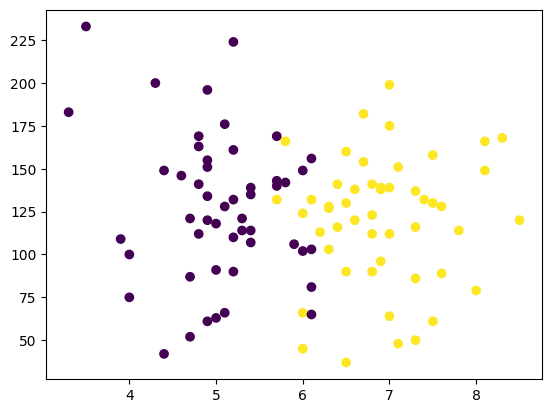

In [95]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [96]:
X = df.iloc[:,0:2]
Y = df.iloc[:, -1]

In [ ]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [98]:
Y.shape

(100,)

In [99]:
X_train , X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2)

In [100]:
X_train

,cgpa,iq
73,4.9,61.0
59,4.8,112.0
83,7.5,130.0
27,6.0,124.0
2,5.3,121.0
...,...,...
31,3.9,109.0
12,5.4,139.0
76,4.9,155.0
42,7.6,89.0


In [101]:
X_test

,cgpa,iq
93,6.8,112.0
74,6.7,154.0
97,6.7,182.0
24,4.7,121.0
71,6.1,132.0
26,7.0,199.0
62,6.0,102.0
75,4.8,169.0
34,4.8,163.0
11,6.9,138.0


In [102]:
Y_train

73    0
59    0
83    1
27    1
2     0
     ..
31    0
12    0
76    0
42    1
87    1
Name: placement, Length: 80, dtype: int64

In [103]:
Y_test

93    1
74    1
97    1
24    0
71    1
26    1
62    0
75    0
34    0
11    1
4     0
33    0
80    0
58    1
52    1
46    0
44    1
0     1
96    0
54    1
Name: placement, dtype: int64

In [104]:
scaler = StandardScaler()

In [105]:
X_train = scaler.fit_transform(X_train)

In [106]:
X_train

array([[-0.90499158, -1.53774514],
       [-0.99067126, -0.22629025],
       [ 1.32268001,  0.23657617],
       [ 0.03748486,  0.08228737],
       [-0.56227288,  0.00514296],
       [-0.81931191, -0.07200144],
       [ 1.15132065, -0.8948751 ],
       [-0.4765932 , -0.17486065],
       [-0.4765932 ,  0.36515018],
       [ 0.55156292, -0.02057184],
       [ 2.00811742,  1.21373864],
       [ 1.15132065, -1.82060795],
       [-1.67610867, -1.17773791],
       [-2.10450706,  2.88520074],
       [-0.21955417,  0.49372419],
       [ 0.80860195, -0.63772708],
       [ 1.23700033,  0.28800578],
       [ 0.12316454, -1.43488593],
       [-0.4765932 , -0.35486426],
       [ 0.46588324, -0.79201589],
       [ 0.46588324, -2.15490037],
       [-0.81931191, -0.76630109],
       [ 1.15132065,  0.41657979],
       [ 0.9799613 ,  0.77658701],
       [ 0.38020356, -0.12343105],
       [ 0.72292227,  0.51943899],
       [ 0.29452389, -0.45772347],
       [-0.64795255, -0.27771986],
       [ 0.03748486,

In [107]:
X_test = scaler.transform(X_test)

In [108]:
X_test

array([[ 0.72292227, -0.22629025],
       [ 0.63724259,  0.85373141],
       [ 0.63724259,  1.57374586],
       [-1.07635094,  0.00514296],
       [ 0.12316454,  0.28800578],
       [ 0.89428162,  2.01089748],
       [ 0.03748486, -0.48343827],
       [-0.99067126,  1.23945344],
       [-0.99067126,  1.08516463],
       [ 0.80860195,  0.44229459],
       [-0.13387449,  0.54515379],
       [ 0.03748486,  0.7251574 ],
       [-0.90499158,  1.93375308],
       [ 1.75107839, -1.07487871],
       [ 0.89428162,  1.39374225],
       [-0.56227288, -0.17486065],
       [ 1.32268001, -1.53774514],
       [ 0.72292227,  0.05657256],
       [-1.33338997, -2.02632637],
       [ 0.38020356,  0.51943899]])

In [109]:
clf = LogisticRegression()

In [110]:
#model traning in ml
clf.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [111]:
ypred =clf.predict(X_test)

In [112]:
Y_test

93    1
74    1
97    1
24    0
71    1
26    1
62    0
75    0
34    0
11    1
4     0
33    0
80    0
58    1
52    1
46    0
44    1
0     1
96    0
54    1
Name: placement, dtype: int64

In [113]:
accuracy_score(Y_test, ypred)

0.95

<Axes: >

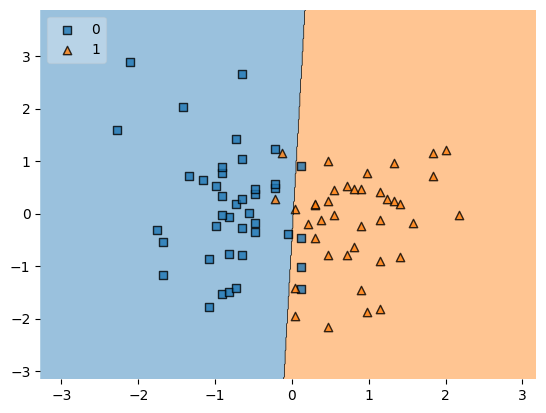

In [119]:
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

In [122]:
pickle.dump(clf, open('model.pkl', 'wb'))